# EV Intelligence System

## Objective

Develop a machine learning system that analyzes EV telemetry data to:

- Predict driving behavior (Eco, Normal, Aggressive)
- Estimate energy consumption
- Generate driving recommendations
- Support efficient EV operation

## Workflow

1. Data preprocessing
2. Feature engineering
3. Exploratory Data Analysis
4. Model development
5. Explainability
6. Model export

In [121]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
import joblib

In [27]:
# Loading dataset
df =pd.read_excel(r"C:\Users\Admin\Desktop\Shrawani\Projects\EV\EV intelligence system\data\EV_data.xlsx")

# Dataset Overview

The dataset contains telemetry collected from an Electric Vehicle (EV) during driving sessions.

Each record represents the operational state of the vehicle at a specific timestamp and includes measurements from the Battery Management System (BMS), Motor Control Unit (MCU), vehicle speed, torque, temperatures, and battery state of charge.

The objective is to analyze this telemetry to understand driving behavior and energy consumption patterns.

In [28]:
# first 5 rows from dataset
df.head()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_temp,Motor_temp,Accel_pedal,MCU_torque,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage,MCU_AC_Current,Odometer
0,115.8,-3,1,1,-3.0,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-150.5,-94,3.5,687.2,21.5,56.7,10010.7
1,115.9,-3,1,1,-3.0,688.4,-3.5,688.4,100.0,100.0,...,35,31,4,-139.8,-94,3.1,688.0,20.7,53.9,10010.7
2,116.2,-3,1,1,-2.5,688.6,-3.5,688.6,100.0,100.0,...,35,31,4,-114.8,-97,2.5,688.7,20.1,46.2,10010.7
3,116.4,-3,1,1,-2.5,688.6,-3.0,688.6,100.0,100.0,...,35,31,3,-100.6,-99,2.3,687.3,20.3,41.4,10010.7
4,116.5,-3,1,1,-3.0,688.6,-3.0,688.6,100.0,100.0,...,35,31,0,-64.5,-93,1.8,687.9,17.8,39.2,10010.7


In [29]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 167908
Number of Columns : 27


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167908 entries, 0 to 167907
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Time                     167908 non-null  float64
 1   Speed                    167908 non-null  int64  
 2   Crank                    167908 non-null  int64  
 3   Ignition                 167908 non-null  int64  
 4   A_Batt_Current           167908 non-null  float64
 5   A_Batt_Voltage           167908 non-null  float64
 6   B_Batt_Current           167908 non-null  float64
 7   B_Batt_Voltage           167908 non-null  float64
 8   A_Batt_soc               167908 non-null  float64
 9   B_Batt_soc               167908 non-null  float64
 10  B_Batt_Charge_energy     167908 non-null  float64
 11  B_Batt_Discharge_energy  167908 non-null  float64
 12  B_Batt_Regen_energy      167908 non-null  float64
 13  A_Batt_Charge_energy     167908 non-null  float64
 14  A_Ba

## Missing values

In [31]:
df.isnull().sum()

Time                       0
Speed                      0
Crank                      0
Ignition                   0
A_Batt_Current             0
A_Batt_Voltage             0
B_Batt_Current             0
B_Batt_Voltage             0
A_Batt_soc                 0
B_Batt_soc                 0
B_Batt_Charge_energy       0
B_Batt_Discharge_energy    0
B_Batt_Regen_energy        0
A_Batt_Charge_energy       0
A_Batt_Discharge energy    0
A_Batt_Regen_energy        0
Torque                     0
MCU_temp                   0
Motor_temp                 0
Accel_pedal                0
MCU_torque                 0
MCU_Speed                  0
MCU_Current_DC             0
MCU_Voltage_DC             0
MCU_AC_Voltage             0
MCU_AC_Current             0
Odometer                   0
dtype: int64

#### Observation

- This dataset does not contain any missing values

## Duplicate Records

In [32]:
df.duplicated().sum()

np.int64(0)

#### Observation

- This dataset does not contain any missing values

## Statistical Summary

In [33]:
df.describe()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_temp,Motor_temp,Accel_pedal,MCU_torque,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage,MCU_AC_Current,Odometer
count,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,...,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000,167908.000000
mean,8395.350000,37.528605,0.994985,0.999071,-18.077879,677.564992,-18.590037,677.564992,68.806759,68.392492,...,34.484009,38.733056,53.917133,147.176479,1212.308407,37.067276,673.928479,312.494297,42.492583,10074.017006
std,4847.100884,17.648891,0.070637,0.030467,14.813569,5.518851,16.052850,5.518851,17.934187,18.409098,...,6.302457,7.574951,28.784129,184.179764,568.836951,32.949798,48.401498,143.444061,31.169425,558.299602
min,0.000000,-3.000000,0.000000,0.000000,-75.000000,0.000000,-84.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-891.900000,-123.000000,-108.900000,0.000000,0.000000,0.000000,0.000000
25%,4197.675000,38.000000,1.000000,1.000000,-25.500000,672.500000,-26.500000,672.500000,53.200000,52.300000,...,28.000000,32.000000,41.000000,68.700000,1232.000000,15.100000,672.100000,331.300000,25.100000,10055.500000
50%,8395.350000,46.000000,1.000000,1.000000,-19.000000,679.100000,-19.500000,679.100000,65.700000,65.900000,...,38.000000,39.000000,64.000000,145.800000,1475.000000,38.000000,678.800000,377.200000,39.200000,10110.200000
75%,12593.025000,48.000000,1.000000,1.000000,-9.000000,681.500000,-8.500000,681.500000,85.100000,85.000000,...,40.000000,46.000000,73.000000,207.600000,1557.000000,52.700000,681.500000,393.200000,54.700000,10151.700000
max,16790.700000,56.000000,1.000000,1.000000,62.000000,692.000000,71.500000,692.000000,100.000000,100.000000,...,47.000000,55.000000,100.000000,1579.700000,1812.000000,187.000000,693.100000,474.200000,272.500000,10205.700000


### Vehicle Speed
- The average vehicle speed is 37.53 km/h, with most observations between 38 km/h and 48 km/h.
- The maximum recorded speed is 56 km/h, indicating that the dataset primarily represents urban or controlled driving conditions.
- A minimum speed of -3 km/h may represent reverse motion or a sensor artifact and should be investigated further.
### Battery Current & Voltage
- Both battery packs exhibit an average current of approximately -18 A, indicating battery discharge during normal vehicle operation.
- Positive current values likely correspond to regenerative braking or charging events.
- Battery voltage remains relatively stable around 678 V, suggesting consistent battery performance.
### Battery State of Charge (SOC)
- The average SOC is approximately 68% for both battery packs.
- SOC values span the full operational range (0–100%), making it a valuable feature for analyzing energy consumption and driving efficiency.
### Motor & MCU Temperature
- The average Motor Temperature is 38.7°C, while the MCU Temperature averages 34.5°C.
- Most values fall within a normal operating range, indicating stable thermal conditions during vehicle operation.
### Motor Torque
- Motor torque shows substantial variability, ranging from -891.9 Nm to 1579.7 Nm.
- Negative torque values likely correspond to regenerative braking, where the motor recovers energy.
### Electrical Current
- DC and AC current values exhibit considerable variation, reflecting different power demands under varying driving conditions.
- These features are expected to be important predictors of driving behavior.
### Odometer
- The odometer increases from 0 km to approximately 10,206 km.
- As a cumulative measure, it may not directly contribute to driving behavior prediction and should be evaluated carefully before model training.

## Key Observations
- The dataset captures a wide range of EV operating conditions.
- Most telemetry values fall within realistic operating limits.
- A few zero or negative values require domain-specific interpretation rather than immediate removal.
- Features such as Speed, Motor Temperature, MCU Temperature, Battery SOC, Torque, and Electrical Current are expected to play a significant role in
- predicting driving behavior.

In [34]:
#Let's remove unnessesary rows by considering valid conditions

In [35]:
df=df[(df["Ignition"]==1) & (df["Crank"]==1) & (df["Speed"]>0)].reset_index(drop=True)

In [36]:
df.shape

(145058, 27)

# Feature Engineering

Feature engineering is the process of creating new variables from the existing telemetry data to better capture vehicle behavior and improve model performance.

Instead of relying only on raw sensor measurements, domain-specific features were engineered to represent electrical power consumption, vehicle dynamics, thermal behavior, and battery characteristics. These engineered features provide more meaningful information for both energy consumption prediction and driving behavior classification.

## 1. Time-based Features

The telemetry data contains timestamp information for each observation. To calculate rate-based quantities such as acceleration and jerk, the time difference between consecutive observations is computed.

The `dt` feature represents the elapsed time between two consecutive telemetry records and serves as the foundation for subsequent driving dynamics calculations.

In [37]:
df["dt"]=df["Time"].diff().fillna(0.1)

In [67]:
df["dt"].describe()

count    145058.000000
mean          0.112433
std         302.803822
min      -15588.700000
25%           0.100000
50%           0.100000
75%           0.100000
max        9516.300000
Name: dt, dtype: float64

In [68]:
df["dt"].value_counts().head(10)

dt
0.1    76983
0.1    21096
0.1    15136
0.1    14991
0.1     4014
0.1     3928
0.1     1564
0.2      562
0.2      459
0.2      283
Name: count, dtype: int64

In [69]:
df["Time"].describe()

count    145058.000000
mean       8499.224659
std        4904.571441
min         137.100000
25%        4262.625000
50%        8023.550000
75%       12860.375000
max       16790.700000
Name: Time, dtype: float64

In [70]:
df["Time"].head(20)

0     137.1
1     137.2
2     137.3
3     137.4
4     137.5
5     137.6
6     167.8
7     167.9
8     168.0
9     472.2
10    472.3
11    472.4
12    472.5
13    472.6
14    472.7
15    472.8
16    483.6
17    483.7
18    483.8
19    483.9
Name: Time, dtype: float64

In [71]:
df["Time"].tail(20)

145038     6926.3
145039     6926.4
145040     6926.5
145041     6926.6
145042     6926.7
145043     6926.8
145044     6926.9
145045     6927.0
145046     6927.1
145047     6927.2
145048     6927.3
145049     6927.4
145050     6927.5
145051     6927.6
145052     6927.7
145053     6927.8
145054     6927.9
145055    16444.2
145056    16446.2
145057    16446.3
Name: Time, dtype: float64

In [72]:
(df["Time"].diff() < 0).sum()

np.int64(55)

## 2. Electrical Power Features

Electrical power is one of the most important indicators of energy consumption in an electric vehicle.

Power is calculated using the relationship:

Power = Voltage × Current

Power is computed separately for Battery Pack A and Battery Pack B, and then combined to estimate the total electrical power delivered by the battery system.

Higher power demand generally corresponds to increased energy consumption and more aggressive driving behavior.

In [38]:
df['Power_A'] = df['A_Batt_Voltage'] * df['A_Batt_Current']
df['Power_B'] = df['B_Batt_Voltage'] * df['B_Batt_Current']
df['Total_Power'] = df['Power_A'] + df['Power_B']

## 3. Driving Dynamics Features

Driving behavior is influenced not only by vehicle speed but also by how quickly the speed changes over time.

To capture these dynamic characteristics, acceleration and jerk are computed.

- **Acceleration** measures the rate of change of speed and helps identify rapid acceleration or braking events.
- **Jerk** measures the rate of change of acceleration and reflects sudden changes in driver input.

These features help distinguish between smooth and aggressive driving styles.

In [73]:
window=600
df['Acceleration'] = (df['Speed'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)
df['Jerk'] = (df['Acceleration'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)

**Note:**

Acceleration and Jerk were engineered to capture vehicle dynamics and were initially considered for driving behavior analysis. However, further investigation revealed that the telemetry dataset consists of multiple driving sessions, leading to discontinuities in the time variable. Consequently, these features were retained for exploratory analysis but were not used for rule-based target variable generation.

## 4. Torque-based Features

Torque represents the rotational force generated by the electric motor and is directly related to vehicle propulsion.

Two additional torque-based features are created:

- **Torque Load** estimates the mechanical workload by combining vehicle speed and motor torque.
- **Torque Ratio** normalizes torque with respect to speed, allowing comparison across different operating conditions.

These features provide valuable information about vehicle load and driving intensity.

In [40]:
df['Torque_Load'] = df['Torque'] * df['Speed']
df['Torque_Ratio'] = df['Torque'] / (df['Speed']+1)

## 5. Thermal Features

The thermal behavior of an electric vehicle provides important information about component operating conditions.

The temperature difference between the electric motor and the Motor Control Unit (MCU) is calculated to capture thermal imbalance during vehicle operation.

Large temperature differences may indicate increased electrical or mechanical loading.

In [41]:
df['Temp_diff'] = df['Motor_temp'] - df['MCU_temp']

## 6. Battery State of Charge (SOC) Features

Battery State of Charge (SOC) represents the remaining energy available in the battery pack.

Two additional SOC-based features are engineered:

- **Total SOC** represents the combined battery state of both battery packs.
- **SOC Drop** measures the change in battery charge between consecutive observations, providing an indication of battery discharge over time.

These features are expected to improve the prediction of vehicle energy consumption.

In [42]:
df["Total_SOC"]=df["A_Batt_soc"]+df["B_Batt_soc"]

In [43]:
df['SOC_drop'] = df['Total_SOC'].diff().fillna(0)

## 7. Power Magnitude

The battery current in the telemetry dataset follows the EV convention where negative current indicates battery discharge and positive current indicates charging or regenerative braking.

Since the objective is to quantify the electrical demand placed on the battery, only the magnitude of power consumption is required for target variable engineering.

Therefore, the absolute value of the total electrical power is calculated to represent the intensity of power demand irrespective of its direction.

In [74]:
df["Power_Magnitude"] = df["Total_Power"].abs()

## Summary of Engineered Features

| Category                | Engineered Features                            |
| ----------------------- | ---------------------------------------------- |
| **Time Features**       | dt                                             |
| **Power Features**      | Power_A, Power_B, Total_Power, Power_Magnitude |
| **Vehicle Dynamics**    | Acceleration, Jerk                             |
| **Mechanical Features** | Torque_Load, Torque_Ratio                      |
| **Thermal Features**    | Temp_diff                                      |
| **Battery Features**    | Total_SOC, SOC_drop                            |



# Quantile Analysis

To create rule-based driving behavior labels, the distributions of the selected telemetry features are analyzed using quartiles.

The selected features represent different aspects of vehicle operation:

- Accelerator Pedal → Driver intent
- Speed → Vehicle motion
- Torque Load → Mechanical workload
- Power Magnitude → Electrical energy demand
- MCU DC Current → Motor electrical load

Quartiles provide data-driven thresholds for identifying low, medium, and high operating conditions without relying on arbitrary values.

In [77]:
# Features selected for rule-based driving behavior labeling

target_features = [
    "Accel_pedal",
    "Speed",
    "Torque_Load",
    "Power_Magnitude",
    "MCU_Current_DC"
]



In [78]:
# Calculate quartiles

quantiles = df[target_features].quantile([0.25, 0.50, 0.75]).T


In [79]:
quantiles.columns = ["25th Percentile (Q1)",
                     "50th Percentile (Median)",
                     "75th Percentile (Q3)"]

quantiles.style.format("{:.2f}")

,25th Percentile (Q1),50th Percentile (Median),75th Percentile (Q3)
Accel_pedal,56.00,67.00,75.00
Speed,44.00,46.00,49.00
Torque_Load,5004.80,7324.80,9845.75
Power_Magnitude,21193.20,28822.90,37996.25
MCU_Current_DC,28.40,41.40,56.00


## Interpretation

The quartiles summarize the distribution of each telemetry feature and serve as the basis for defining driving intensity levels.

For each feature:

- Values less than or equal to the 25th percentile (Q1) represent **Low** operating conditions.
- Values between the 25th percentile (Q1) and the 75th percentile (Q3) represent **Medium** operating conditions.
- Values greater than the 75th percentile (Q3) represent **High** operating conditions.

Using percentile-based thresholds ensures that the rule-based driving behavior labels are derived from the characteristics of the dataset rather than arbitrary cutoff values.

# Rule-Based Feature Scoring

Each telemetry feature is converted into a numerical score based on its quartile distribution.

For every feature:

- **Low (≤ Q1)** → Score **0**
- **Medium (Q1 < value ≤ Q3)** → Score **1**
- **High (> Q3)** → Score **2**

Using a common scoring function ensures consistency across all features and makes the target engineering process transparent and reproducible.

In [86]:
thresholds = {
    feature: {
        "Q1": quantiles.loc[feature, "25th Percentile (Q1)"],
        "Q3": quantiles.loc[feature, "75th Percentile (Q3)"]
    }
    for feature in quantiles.index
}

thresholds

{'Accel_pedal': {'Q1': np.float64(56.0), 'Q3': np.float64(75.0)},
 'Speed': {'Q1': np.float64(44.0), 'Q3': np.float64(49.0)},
 'Torque_Load': {'Q1': np.float64(5004.8), 'Q3': np.float64(9845.75)},
 'Power_Magnitude': {'Q1': np.float64(21193.199999999997),
  'Q3': np.float64(37996.25)},
 'MCU_Current_DC': {'Q1': np.float64(28.4), 'Q3': np.float64(56.0)}}

In [87]:
df["Accel_score"] = df["Accel_pedal"].apply(
    lambda x: score_feature(
        x,
        thresholds["Accel_pedal"]["Q1"],
        thresholds["Accel_pedal"]["Q3"]
    )
)

df["Speed_score"] = df["Speed"].apply(
    lambda x: score_feature(
        x,
        thresholds["Speed"]["Q1"],
        thresholds["Speed"]["Q3"]
    )
)

df["Torque_score"] = df["Torque_Load"].apply(
    lambda x: score_feature(
        x,
        thresholds["Torque_Load"]["Q1"],
        thresholds["Torque_Load"]["Q3"]
    )
)

df["Power_score"] = df["Power_Magnitude"].apply(
    lambda x: score_feature(
        x,
        thresholds["Power_Magnitude"]["Q1"],
        thresholds["Power_Magnitude"]["Q3"]
    )
)

df["Current_score"] = df["MCU_Current_DC"].apply(
    lambda x: score_feature(
        x,
        thresholds["MCU_Current_DC"]["Q1"],
        thresholds["MCU_Current_DC"]["Q3"]
    )
)

In [88]:
score_columns = [
    "Accel_score",
    "Speed_score",
    "Torque_score",
    "Power_score",
    "Current_score"
]

df[score_columns].head()

,Accel_score,Speed_score,Torque_score,Power_score,Current_score
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0


# Driving Score Calculation

Each telemetry feature contributes equally to the overall driving behavior score.

The individual feature scores are summed to obtain a **Driving Score**, which represents the combined driving intensity for each observation.

A higher score indicates greater driver demand, higher electrical power consumption, and increased mechanical load.

Possible Driving Score values range from **0** (least aggressive) to **10** (most aggressive).

In [90]:
score_columns = [
    "Accel_score",
    "Speed_score",
    "Torque_score",
    "Power_score",
    "Current_score"
]

df["Driving_Score"] = df[score_columns].sum(axis=1)

df["Driving_Score"].describe()

count    145058.000000
mean          4.811979
std           2.719255
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: Driving_Score, dtype: float64

In [91]:
df["Driving_Score"].value_counts().sort_index()

Driving_Score
0     11927
1     14142
2      7740
3      5923
4     13054
5     41339
6     11127
7     12660
8     11306
9     12516
10     3324
Name: count, dtype: int64

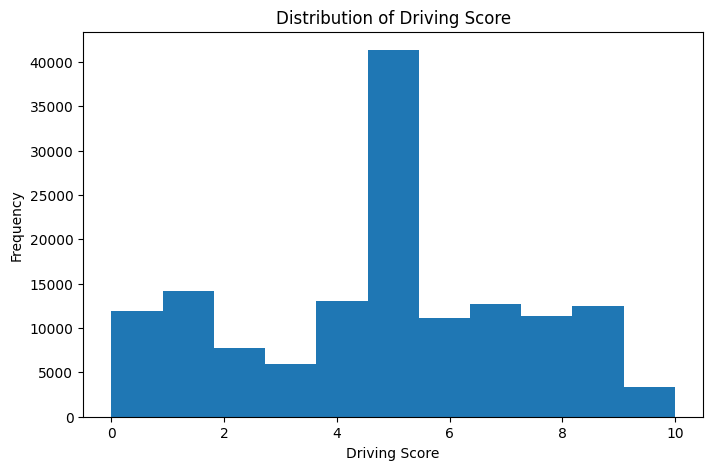

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Driving_Score"], bins=11)

plt.title("Distribution of Driving Score")
plt.xlabel("Driving Score")
plt.ylabel("Frequency")

plt.show()

# Driving Style Label Generation

The final driving behavior labels are derived from the overall Driving Score using quartile-based thresholds.

This approach maintains consistency with the feature scoring methodology by using the statistical distribution of the Driving Score rather than manually selected cutoff values.

The labels are assigned as follows:

- **Eco:** Driving Score ≤ 25th percentile (Q1)
- **Normal:** 25th percentile < Driving Score ≤ 75th percentile (Q3)
- **Aggressive:** Driving Score > 75th percentile (Q3)

Using quartile-based thresholds provides an objective and reproducible approach for generating driving behavior labels from unlabeled telemetry data.

In [93]:
def assign_driving_style(score):
    if score <= 3:
        return "Eco"
    elif score <= 7:
        return "Normal"
    else:
        return "Aggressive"

df["Driving_style"] = df["Driving_Score"].apply(assign_driving_style)

In [94]:
df["Driving_style"].value_counts()

Driving_style
Normal        78180
Eco           39732
Aggressive    27146
Name: count, dtype: int64

In [95]:
validation = (
    df.groupby("Driving_style")[
        [
            "Accel_pedal",
            "Speed",
            "Torque_Load",
            "Power_Magnitude",
            "MCU_Current_DC"
        ]
    ]
    .mean()
    .round(2)
)

validation

,Accel_pedal,Speed,Torque_Load,Power_Magnitude,MCU_Current_DC
Driving_style,,,,,
Aggressive,84.56,44.60,14589.51,54034.26,84.65
Eco,35.87,37.73,1233.25,15269.93,10.91
Normal,67.19,45.97,7785.73,30545.58,44.61


#### Observations

The engineered driving style labels exhibit meaningful differences across the selected telemetry features.

- Accelerator pedal position increases steadily from Eco to Aggressive driving, indicating higher driver demand.
- Torque Load shows a substantial increase, reflecting greater mechanical load during aggressive driving.
- Power Magnitude increases significantly, confirming higher electrical energy consumption.
- MCU DC Current also increases consistently, indicating increased motor current demand.
- Vehicle Speed remains relatively similar between Normal and Aggressive driving. This suggests that aggressive driving is characterized more by rapid acceleration, higher torque, and greater power demand than by sustained high speed.

Overall, the observed trends indicate that the rule-based target engineering methodology successfully captures realistic driving behavior patterns and provides a reliable target variable for the classification model.

# Driving Style Classification

## Problem Statement

The objective of this model is to classify the driving behavior of an electric vehicle into one of three categories:

- Eco
- Normal
- Aggressive

Unlike traditional supervised learning datasets, the telemetry data did not contain predefined driving behavior labels. Therefore, a rule-based target engineering approach was developed using multiple telemetry features, including accelerator pedal position, vehicle speed, torque load, electrical power demand, and motor controller current.

The engineered driving style labels are used as the target variable for training a multi-class classification model capable of predicting driving behavior from real-time EV telemetry data.

In [96]:
df.columns

Index(['Time', 'Speed', 'Crank', 'Ignition', 'A_Batt_Current',
       'A_Batt_Voltage', 'B_Batt_Current', 'B_Batt_Voltage', 'A_Batt_soc',
       'B_Batt_soc', 'B_Batt_Charge_energy', 'B_Batt_Discharge_energy',
       'B_Batt_Regen_energy', 'A_Batt_Charge_energy',
       'A_Batt_Discharge energy', 'A_Batt_Regen_energy', 'Torque', 'MCU_temp',
       'Motor_temp', 'Accel_pedal', 'MCU_torque', 'MCU_Speed',
       'MCU_Current_DC', 'MCU_Voltage_DC', 'MCU_AC_Voltage', 'MCU_AC_Current',
       'Odometer', 'dt', 'Power_A', 'Power_B', 'Total_Power', 'Acceleration',
       'Jerk', 'Torque_Load', 'Torque_Ratio', 'Temp_diff', 'Total_SOC',
       'SOC_drop', 'Power_Magnitude', 'Accel_score', 'Speed_score',
       'Torque_score', 'Power_score', 'Current_score', 'Driving_Score',
       'Driving_style'],
      dtype='object')

# Feature Selection

The input features were selected to capture different aspects of electric vehicle operation while avoiding data leakage.

Features directly involved in generating the target variable (Driving Score, intermediate score columns, and Driving Style) were excluded.

The final feature set includes variables representing:

- Driver input
- Vehicle motion
- Mechanical load
- Electrical demand
- Thermal characteristics
- Battery state

In [97]:
selected_features = [
    "Speed",
    "Accel_pedal",
    "Torque",
    "MCU_torque",
    "MCU_Speed",
    "MCU_Current_DC",
    "MCU_Voltage_DC",
    "MCU_AC_Current",
    "MCU_AC_Voltage",
    "MCU_temp",
    "Motor_temp",
    "Total_SOC",
    "Torque_Load",
    "Power_Magnitude",
    "Temp_diff"
]

X = df[selected_features]

y = df["Driving_style"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (145058, 15)
Target Shape : (145058,)


# Feature Correlation Analysis

Before training the classification model, the relationships among the selected input features are examined using a correlation matrix.

Correlation analysis helps identify highly correlated variables that may contain redundant information. Removing redundant features can improve model interpretability and reduce multicollinearity, particularly for linear models such as Logistic Regression.

The Pearson correlation coefficient ranges from **-1** to **1**:

- **+1** indicates a perfect positive correlation.
- **0** indicates no linear relationship.
- **-1** indicates a perfect negative correlation.

The correlation heatmap provides a visual representation of these relationships and supports informed feature selection.

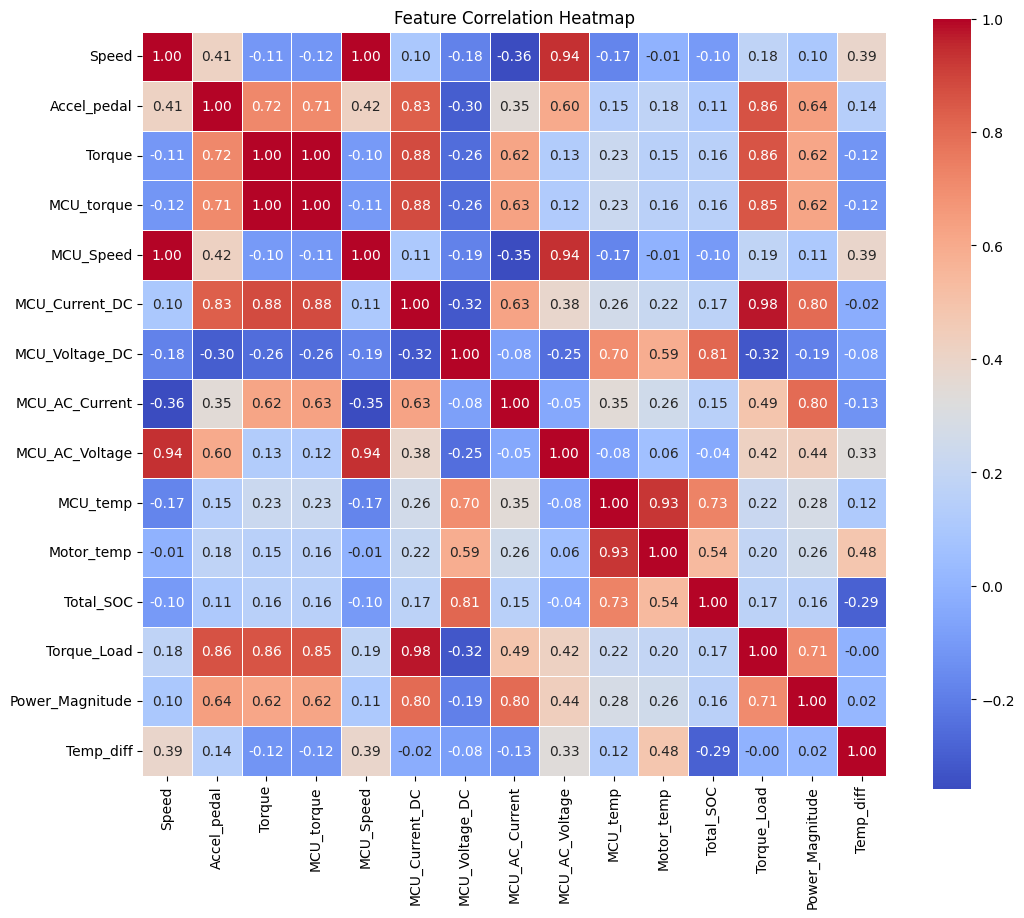

In [98]:
# Correlation matrix
corr_matrix = X.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Interpretation

The correlation analysis identified several highly correlated feature pairs, indicating redundant information.

To improve model interpretability and reduce multicollinearity, one representative feature was retained from each highly correlated pair based on engineering relevance and explainability.

For example:

- Vehicle Speed was retained instead of MCU Speed.
- Torque was retained instead of MCU Torque.
- Torque Load was retained instead of MCU DC Current.
- Motor Temperature was retained instead of MCU Temperature.
- Total SOC was retained instead of MCU DC Voltage.
- Power Magnitude was retained instead of MCU AC Current.

This feature selection strategy reduces redundancy while preserving information related to vehicle dynamics, battery behavior, electrical demand, and thermal characteristics.

In [102]:
high_corr = high_corr[high_corr > 0.80]

high_corr_df = (
    high_corr
    .reset_index()
)

high_corr_df.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr_df

,Feature 1,Feature 2,Correlation
0,Speed,MCU_Speed,0.999352
1,Torque,MCU_torque,0.995410
2,MCU_Current_DC,Torque_Load,0.977908
3,MCU_Speed,MCU_AC_Voltage,0.938120
4,Speed,MCU_AC_Voltage,0.936501
5,MCU_temp,Motor_temp,0.926844
6,MCU_torque,MCU_Current_DC,0.882501
7,Torque,MCU_Current_DC,0.879587
8,Accel_pedal,Torque_Load,0.864076
9,Torque,Torque_Load,0.858703


### Feature Selection Summary Table

| Feature Removed | Feature Retained | Reason                                     |
| --------------- | ---------------- | ------------------------------------------ |
| MCU_Speed       | Speed            | More interpretable vehicle speed           |
| MCU_torque      | Torque           | Represents mechanical output               |
| MCU_Current_DC  | Torque_Load      | Better captures driving effort             |
| MCU_AC_Voltage  | Speed            | Strong redundancy                          |
| MCU_temp        | Motor_temp       | Easier to explain thermally                |
| MCU_Voltage_DC  | Total_SOC        | More meaningful battery indicator          |
| MCU_AC_Current  | Power_Magnitude  | Better representation of electrical demand |


### Define the Feature Sets

#### Model A (15 Features)

In [104]:
full_features = [
    "Speed",
    "Accel_pedal",
    "Torque",
    "MCU_torque",
    "MCU_Speed",
    "MCU_Current_DC",
    "MCU_Voltage_DC",
    "MCU_AC_Current",
    "MCU_AC_Voltage",
    "MCU_temp",
    "Motor_temp",
    "Total_SOC",
    "Torque_Load",
    "Power_Magnitude",
    "Temp_diff"
]

#### Model B (Reduced Features)

In [105]:
reduced_features = [
    "Speed",
    "Accel_pedal",
    "Torque",
    "Motor_temp",
    "Total_SOC",
    "Torque_Load",
    "Power_Magnitude",
    "Temp_diff"
]

### Create the Datasets

In [106]:
X_full = df[full_features]
X_reduced = df[reduced_features]

y = df["Driving_style"]

print("Full Feature Shape:", X_full.shape)
print("Reduced Feature Shape:", X_reduced.shape)
print("Target Shape:", y.shape)

Full Feature Shape: (145058, 15)
Reduced Feature Shape: (145058, 8)
Target Shape: (145058,)


# Feature Set Preparation

To evaluate the impact of feature redundancy on classification performance, two feature sets were prepared.

### Model A – Full Feature Set
Contains all selected telemetry features representing vehicle dynamics, electrical behavior, thermal characteristics, and battery state.

### Model B – Reduced Feature Set
Contains only representative features after removing highly correlated variables identified during the correlation analysis.

Both feature sets will be evaluated using the same machine learning pipeline, allowing a fair comparison between model complexity and predictive performance.

### Train-Test Split

In [109]:
# Split using the full feature set
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [110]:
# Use the same row indices for the reduced feature set
X_train_reduced = X_reduced.loc[X_train_full.index]
X_test_reduced = X_reduced.loc[X_test_full.index]

# Feature Scaling

The selected telemetry features have different numerical ranges.

For example, vehicle speed is measured in tens of kilometers per hour, whereas Torque Load and Power Magnitude can reach several thousand units.

Since Logistic Regression is sensitive to feature scales, the input variables are standardized using **StandardScaler**, which transforms each feature to have:

- Mean = 0
- Standard Deviation = 1

Feature scaling ensures that all variables contribute equally during model training.

In [112]:
scaler_full = StandardScaler()
scaler_reduced = StandardScaler()

X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

In [113]:
print(X_train_full_scaled.shape)
print(X_train_reduced_scaled.shape)

(116046, 15)
(116046, 8)


# Baseline Model: Logistic Regression

Logistic Regression is selected as the baseline classification algorithm because it is simple, interpretable, and computationally efficient.

Although the relationship between telemetry features and driving behavior may not be strictly linear, Logistic Regression provides an excellent baseline against which more complex models can later be compared.

## Train Model A (15 Features)

In [115]:
lr_full = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_full.fit(
    X_train_full_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [116]:
y_pred_full = lr_full.predict(
    X_test_full_scaled
)

In [117]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        y_pred_full
    )
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_full
    )
)

Accuracy
0.9413001516613815

Classification Report

              precision    recall  f1-score   support

  Aggressive       0.91      0.88      0.90      5429
         Eco       0.97      0.96      0.96      7947
      Normal       0.94      0.95      0.95     15636

    accuracy                           0.94     29012
   macro avg       0.94      0.93      0.93     29012
weighted avg       0.94      0.94      0.94     29012



## Model Interpretation

The Logistic Regression baseline achieved an overall accuracy of **94.13%**, demonstrating that the selected telemetry features effectively capture driving behavior.

The Eco and Normal classes achieved excellent precision and recall, indicating clear separation within the feature space.

The Aggressive class showed slightly lower recall, suggesting that some aggressive driving instances exhibit characteristics similar to Normal driving. This is expected in real-world telemetry data, where driving behavior exists on a continuum rather than as strictly separated categories.

Overall, the baseline model provides strong evidence that the engineered target variable and selected features are suitable for driving style classification.

# Logistic Regression (Reduced Feature Set)

The same Logistic Regression model is trained using the reduced feature set obtained after correlation analysis.

The objective is to evaluate whether removing highly correlated features simplifies the model while maintaining comparable predictive performance.

In [118]:
lr_reduced = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_reduced.fit(
    X_train_reduced_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [119]:
y_pred_reduced = lr_reduced.predict(
    X_test_reduced_scaled
)

In [120]:
print("Accuracy")
print(accuracy_score(y_test, y_pred_reduced))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_reduced))

Accuracy
0.9370605266786157

Classification Report

              precision    recall  f1-score   support

  Aggressive       0.90      0.88      0.89      5429
         Eco       0.96      0.96      0.96      7947
      Normal       0.94      0.95      0.94     15636

    accuracy                           0.94     29012
   macro avg       0.93      0.93      0.93     29012
weighted avg       0.94      0.94      0.94     29012



# Feature Set Comparison

Two Logistic Regression models were trained using different feature sets.

- **Model A:** Full feature set (15 features)
- **Model B:** Reduced feature set (8 features)

The reduced model achieved an accuracy of **93.71%**, compared to **94.13%** for the full model, representing a performance decrease of only **0.42%**.

Given the minimal reduction in predictive performance and the substantial reduction in feature count, the reduced feature set was selected for subsequent model development.

This decision improves model simplicity, interpretability, and computational efficiency while maintaining comparable classification performance.

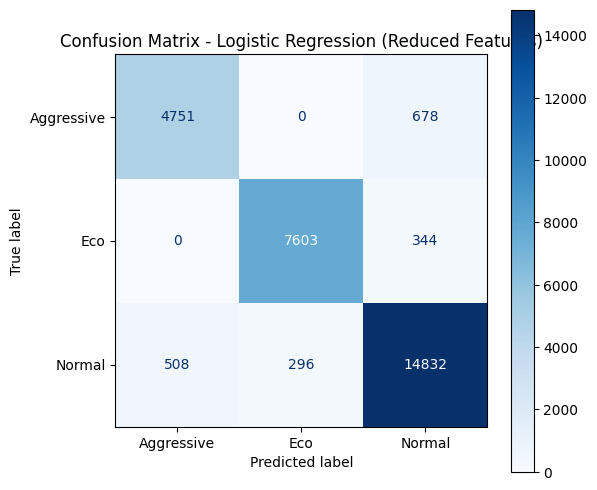

In [123]:
cm = confusion_matrix(y_test, y_pred_reduced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_reduced.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax)

plt.title("Confusion Matrix - Logistic Regression (Reduced Features)")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows that the Logistic Regression model correctly classifies the majority of driving behaviors.

The strongest observation is that **Eco and Aggressive driving styles are never confused**, indicating that the engineered features provide a clear distinction between the two extreme driving behaviors.

Most classification errors occur between **Normal and Aggressive** or **Normal and Eco**, which is expected because real-world driving behavior often transitions gradually rather than belonging to perfectly separated categories.

Overall, the confusion matrix demonstrates that the engineered driving score successfully captures the underlying driving patterns while maintaining strong class separation.

In [48]:
features = [
    'Speed','Torque','MCU_torque','Accel_pedal',
    'MCU_Current_DC','MCU_Voltage_DC',
    'Motor_temp','MCU_temp',
    'Torque_Load','Acceleration','SOC_drop'
]

In [49]:
X=df[features]

In [50]:
y=df["Total_Discharge_energy"]

KeyError: 'Total_Discharge_energy'

In [ ]:
# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [ ]:
reg_model = RandomForestRegressor(n_estimators=100)


In [ ]:
reg_model.fit(X_train, y_train)

In [ ]:
# model Evaluation

In [ ]:
y_test_pred=reg_model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

# Model 2: Driving Style Classification

In [ ]:
features = [
    'Speed','Torque','MCU_torque',
    'MCU_Current_DC','MCU_Voltage_DC',
    'Motor_temp','MCU_temp',
    'Torque_Load','Acceleration','SOC_drop'
]

In [ ]:
X_cls = df[features]
y_cls = df['Driving_style']

In [ ]:
# train-test-split

In [ ]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [ ]:
clf = RandomForestClassifier()

In [ ]:
clf.fit(X_cls_train, y_cls_train)

In [ ]:
y_pred_cls = clf.predict(X_cls_test)
print(classification_report(y_cls_test, y_pred_cls))

In [ ]:
# Let's plot confusion matrix

In [ ]:
cm = confusion_matrix(y_cls_test, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d')

# Explainability using SHAP

In [ ]:
import shap

In [ ]:
X_sample = X_cls_test.sample(1000, random_state=42)

In [ ]:
explainer = shap.TreeExplainer(clf)

In [ ]:
shap_values = explainer.shap_values(X_sample)

In [ ]:
# For Aggressive class

In [ ]:
shap.summary_plot(shap_values[:, :, 0], X_sample)

In [ ]:
# For Eco class

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

In [ ]:
# For Normal class

In [ ]:
shap.summary_plot(shap_values[:, :, 2], X_sample)

In [ ]:
joblib.dump(clf, "model.pkl")